In [3]:
import pandas as pd
import numpy as np

# Imputación de nulos usando métodos avanzados estadísticos
# -----------------------------------------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

# Librerías de visualización
# -----------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('world_data_full_apply_nulos.csv', index_col = 0)

In [5]:
df.head(3)

,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,cpi,cpi_change,currency-code,fertility_rate,forested_area,gasoline_price,gdp,gross_primary_education_enrollment,gross_tertiary_education_enrollment,infant_mortality,largest_city,life_expectancy,maternal_mortality_ratio,minimum_wage,official_language,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,continent
0,Afghanistan,60.0,AF,58.1,652.230,323.0,32.49,93.0,Kabul,8.672,149.90,2.3,AFN,4.47,2.1,0.70,1.910135e+10,104.0,9.7,47.9,Kabul,64.5,638.0,0.43,Pashto,78.4,0.28,NaN,48.9,9.3,71.4,11.12,NaN,33.939110,67.709953,Asia
1,Albania,105.0,AL,43.1,28.748,9.0,11.78,355.0,Tirana,4.536,119.05,1.4,ALL,1.62,28.1,1.36,1.527808e+10,107.0,55.0,7.8,Tirana,78.5,15.0,1.12,Albanian,56.9,1.20,NaN,55.7,18.6,36.6,12.33,NaN,41.153332,20.168331,Europe
2,Algeria,18.0,DZ,17.4,NaN,317.0,24.28,213.0,Algiers,150.006,151.36,2.0,DZD,3.02,0.8,0.28,1.699882e+11,109.9,51.4,20.1,Algiers,76.7,112.0,0.95,Arabic,28.1,1.72,NaN,41.2,37.2,66.1,11.70,NaN,28.033886,1.659626,Africa


Ejercicios visualización
A lo largo de este ejercicio plantearemos una serie de preguntas que tendrás que contestar usando la visualización (podréis usar tanto Seaborn como Matplotlib).

En estos ejercicios debes decidir que gráfica es más adecuada. Puedes utilizar cualquier gráfica vista hasta el momento: gráficas para variables numéricas, categóricas o relación entre ambas.

¿Cuál es el continente con la mayor cantidad de países en el conjunto de datos? Proporciona el porcentaje de países en ese continente.

<Axes: xlabel='count', ylabel='continent'>

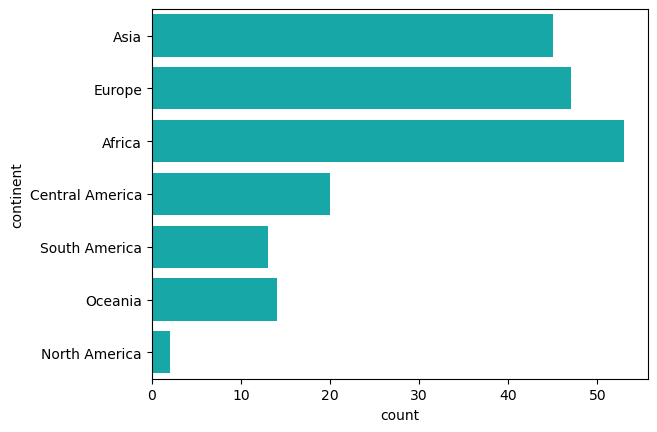

In [7]:
sns.countplot(y = "continent", 
              data = df, 
              color = "c"
              )

In [13]:
df_cantidad_PC = df.groupby("continent")["country"].count().reset_index()
df_cantidad_PC

,continent,country
0,Africa,53
1,Asia,45
2,Central America,20
3,Europe,47
4,North America,2
5,Oceania,14
6,South America,13


In [ ]:

colores = ["c", "cadetblue", "mediumseagreen", "seagreen", "teal", "turquoise", "lightseagreen"]

([<matplotlib.patches.Wedge at 0x16bc9fedfd0>,
 [Text(-0.8323840505609241, 0.7191222374337962, 'Africa'),
  Text(-0.7055490841835029, -0.8439197176318494, 'Asia'),
  Text(0.3836519466934866, -1.0309273416678297, 'Central America'),
  Text(1.0907821014533046, -0.142107027092656, 'Europe'),
  Text(0.8663241493608803, 0.6778513614607167, 'North America'),
  Text(0.6637343453219444, 0.877186820945259, 'Oceania'),
  Text(0.22986419100417166, 1.0757148570573885, 'South America')],
 [Text(-0.4540276639423222, 0.39224849314570703, '27.3%'),
  Text(-0.3848449550091834, -0.46031984598100867, '23.2%'),
  Text(0.20926469819644722, -0.5623240045460889, '10.3%'),
  Text(0.5949720553381661, -0.07751292386872144, '24.2%'),
  Text(0.4725404451059347, 0.36973710625129996, '1.0%'),
  Text(0.3620369156301515, 0.47846553869741393, '7.2%'),
  Text(0.12538046782045725, 0.5867535583949391, '6.7%')])

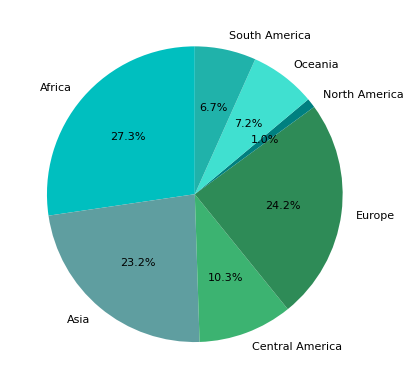

In [16]:
plt.pie("country", labels= "continent", #etiquetas que contiene dentro
        data = df_cantidad_PC, 
        autopct=  '%1.1f%%', 
        colors = colores, 
        textprops={'fontsize': 8}, 
        startangle=90)


¿Cuáles son los 10 países con la mayor área forestal?

In [ ]:
df_pais_forestal = df.groupby("country")["forested_area"].sum().sort_values(ascending=False)
df_pais_forestal

country
Suriname                          98.3
Federated States of Micronesia    91.9
Gabon                             90.0
Seychelles                        88.4
Palau                             87.6
                                  ... 
Nauru                              0.0
South Sudan                        0.0
San Marino                         0.0
Qatar                              0.0
Vatican City                       0.0
Name: forested_area, Length: 195, dtype: float64

In [26]:
df_top = df_pais_forestal.head(10)
df_top

country
Suriname                          98.3
Federated States of Micronesia    91.9
Gabon                             90.0
Seychelles                        88.4
Palau                             87.6
Guyana                            83.9
Laos                              82.1
Solomon Islands                   77.9
Papua New Guinea                  74.1
Finland                           73.1
Name: forested_area, dtype: float64

In [29]:
df_top = df_top.reset_index()

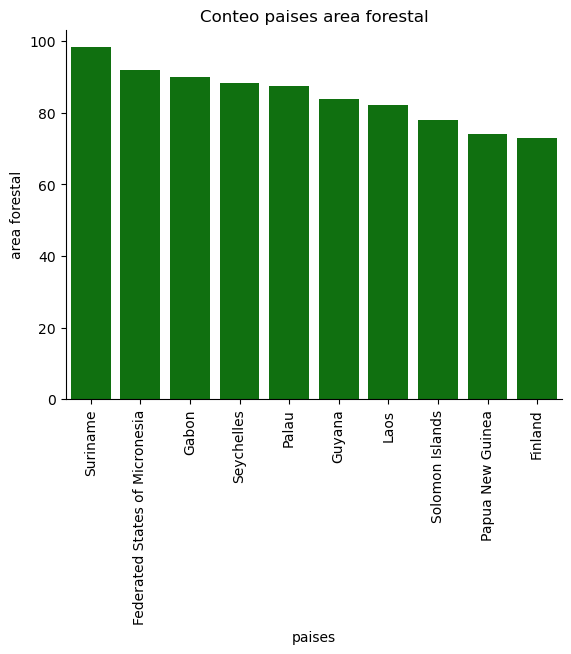

In [31]:
sns.barplot(x='country', y='forested_area', data = df_top, color = 'green')
plt.title('Conteo paises area forestal')
plt.xlabel('paises')
plt.ylabel('area forestal')
plt.xticks(rotation = 90)
plt.gca().spines['right'].set_visible(False) # quitamos la línea de la derecha
plt.gca().spines["top"].set_visible(False) # quitamos la línea de arriba;

¿Cómo se distribuye la densidad de población entre los países?

In [34]:
df_pais_forestal = df.groupby("density")["country"].sum().sort_values(ascending=False)
df_pais_forestal

density
38.000                                         Zimbabwe
314.000                                         Vietnam
2.003                                      Vatican City
79.000                                       Uzbekistan
36.000                                    United States
                               ...                     
26.000                                  AngolaChilePeru
164.000                                         Andorra
18.000     AlgeriaFinlandNew ZealandParaguaySouth Sudan
105.000                                         Albania
60.000                                      Afghanistan
Name: country, Length: 137, dtype: object

In [44]:
df_1 = df.groupby(["continent","country"])["density"].sum().reset_index()
df_1

,continent,country,density
0,Africa,Algeria,18.0
1,Africa,Angola,26.0
2,Africa,Benin,108.0
3,Africa,Botswana,4.0
4,Africa,Burkina Faso,76.0
...,...,...,...
189,South America,Peru,26.0
190,South America,Suriname,4.0
191,South America,Trinidad and Tobago,273.0
192,South America,Uruguay,20.0


C:\Users\Usuario\AppData\Local\Temp\ipykernel_10108\4207789615.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:green'` for the same effect.

  sns.barplot(x='density', y='country', data = df_1, color = 'green', hue='continent')


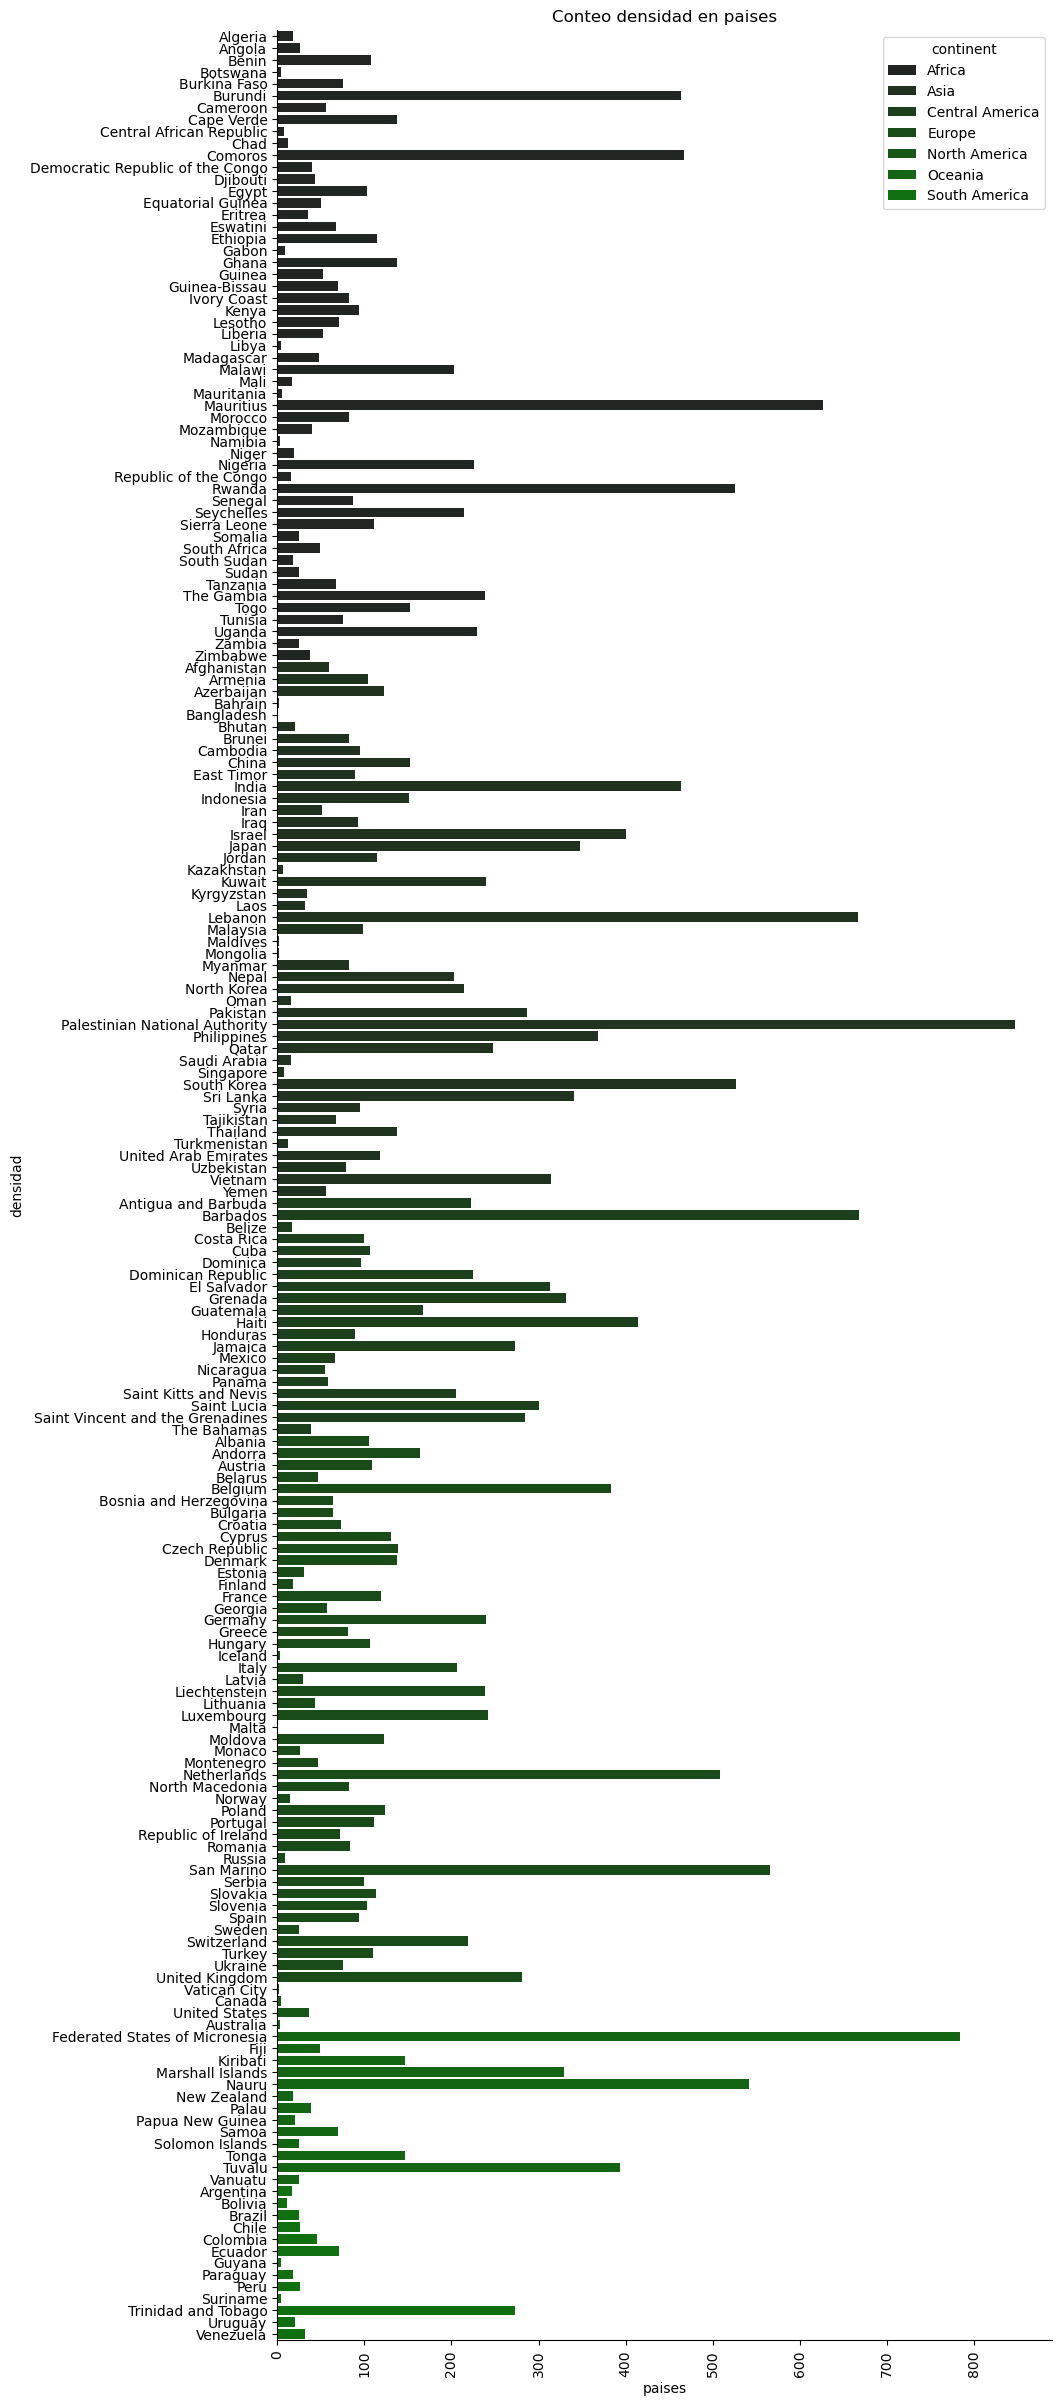

In [52]:
plt.figure(figsize=(10,30))
sns.barplot(x='density', y='country', data = df_1, color = 'green', hue='continent')
plt.title('Conteo densidad en paises')
plt.xlabel('paises')
plt.ylabel('densidad')
plt.xticks(rotation = 90)
plt.gca().spines['right'].set_visible(False) # quitamos la línea de la derecha
plt.gca().spines["top"].set_visible(False) # quitamos la línea de arriba;

C:\Users\Usuario\AppData\Local\Temp\ipykernel_10108\4225481592.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:green'` for the same effect.

  sns.barplot(x='density', y='country', data = df_1.sort_values(by = 'density', ascending=False).head(10), color = 'green', hue='continent')


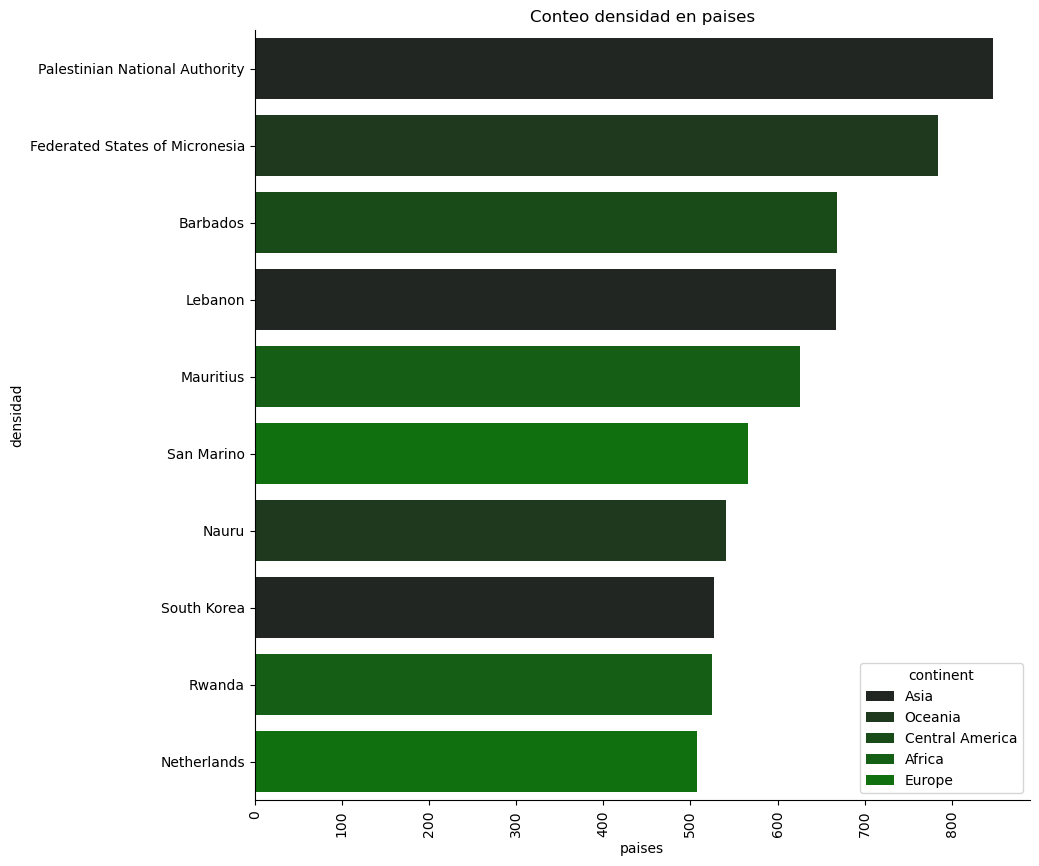

In [56]:
plt.figure(figsize=(10,10))
sns.barplot(x='density', y='country', data = df_1.sort_values(by = 'density', ascending=False).head(10), color = 'green', hue='continent')
plt.title('Conteo densidad en paises')
plt.xlabel('paises')
plt.ylabel('densidad')
plt.xticks(rotation = 90)
plt.gca().spines['right'].set_visible(False) # quitamos la línea de la derecha
plt.gca().spines["top"].set_visible(False) # quitamos la línea de arriba;

los 10 paises que menos tienen

C:\Users\Usuario\AppData\Local\Temp\ipykernel_10108\416890178.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:green'` for the same effect.

  sns.barplot(x='density', y='country', data = df_1.sort_values(by = 'density', ascending=False).tail(10), color = 'green', hue='continent')


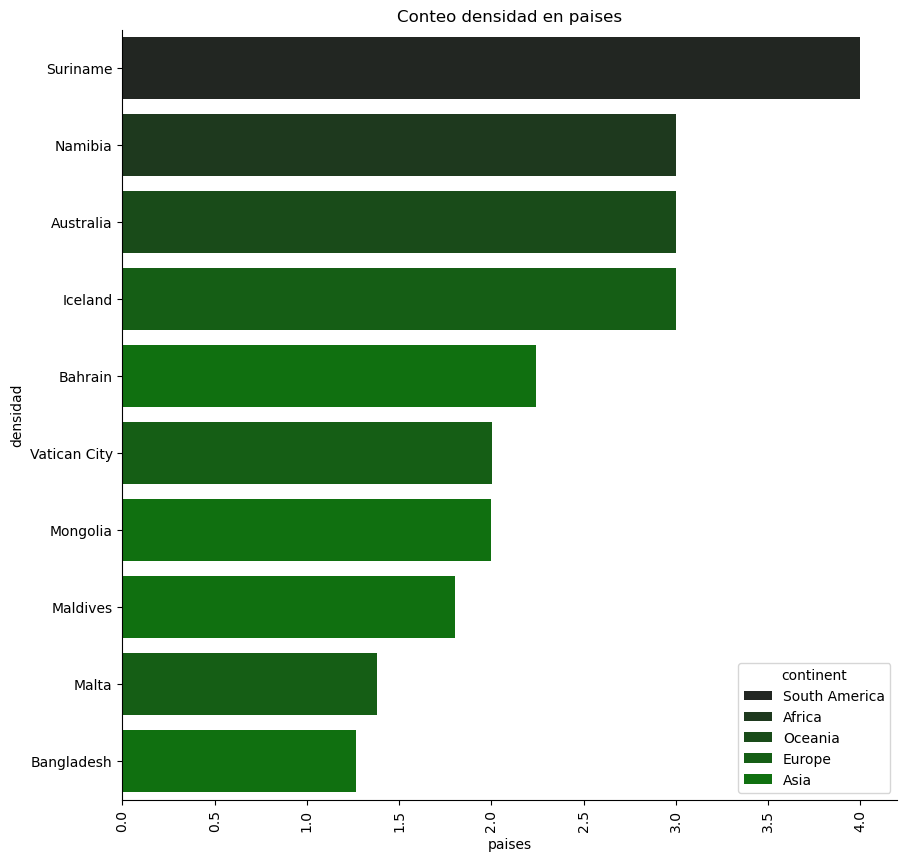

In [57]:
plt.figure(figsize=(10,10))
sns.barplot(x='density', y='country', data = df_1.sort_values(by = 'density', ascending=False).tail(10), color = 'green', hue='continent')
plt.title('Conteo densidad en paises')
plt.xlabel('paises')
plt.ylabel('densidad')
plt.xticks(rotation = 90)
plt.gca().spines['right'].set_visible(False) # quitamos la línea de la derecha
plt.gca().spines["top"].set_visible(False) # quitamos la línea de arriba;

nos faltaria un histograms y un boxplot.

¿Existe una relación entre el PIB y la tasa de desempleo de los países?

¿Cómo se relacionan la tasa de mortalidad infantil y la esperanza de vida?












Requisitos que deben cumplir las gráficas (en caso de usar alguna de ellas):

Todas deben llevar título.

Los nombres de los ejes deben estar en castellano.

En los scatterplot los puntos deben tener un tamaño de 2.

En los scatterplot los puntos deben tener un color diferente al azul.

En los barplot las barras siempre tienen que estar ordenadas de mayor a menor.

En los barplot y countplot las barras tienen que tener un color diferente a los que vienen por defecto.

En los pieplot siempre tenemos que añadir la etiqueta de a que % corresponde cada quesito.